# Kredi Kartı Dolandırıcılığı Tespiti

Önceki egzersizler, bir sinir ağının tüm farklı bileşenlerine daha yakından bakmanızı sağladı:
* sıralı (sequential) yoğun (Dense) bir Sinir Ağı mimarisi,
* derleme (compilation) yöntemi,
* modelin eğitilmesi (fitting).

Şimdi **çok fazla veri içeren** gerçek hayat bir veri seti üzerinde çalışalım!

**Veri seti: `Kredi Kartı İşlemleri (Credit Card Transactions)`**

Bu açık uçlu challenge’da, **kredi kartı işlemlerinden elde edilmiş verilerle** çalışacaksınız.

Bu veriler **hassas** olduğu için, toplam 31 sütundan yalnızca 3’ü bilinmektedir; geri kalanlar verileri **anonimleştirmek** amacıyla dönüştürülmüştür (aslında bunlar, orijinal verilerin **PCA projeksiyonlarıdır**).

Bilinen 3 sütun şunlardır:

* `TIME`: İşlemin, veri setindeki ilk işleme göre geçen süresi  
* `AMOUNT`: İşlem tutarı  
* `CLASS` (hedef değişkenimiz):
    * `0 : geçerli işlem`
    * `1 : sahte (fraud) işlem`

❓ **Soru** ❓ Veri setini indirerek başlayın:
* Kaggle üzerinden: [buradan](https://www.kaggle.com/mlg-ulb/creditcardfraud)
* veya bizim URL’mizden: [buradan](https://d32aokrjazspmn.cloudfront.net/materials/creditcard.csv)

Veriyi yükleyerek `X` ve `y` değişkenlerini oluşturun.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("data/creditcard.csv")
print(data.shape)

X = data.drop(columns=["Class"])
y = data["Class"]

print("Fraud sayısı:", y.sum(), f"(%{100 * y.mean():.3f})")
data.head()

(284807, 31)
Fraud sayısı: 492 (%0.173)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Sınıfların yeniden dengelenmesi

In [2]:
# Sınıf dengesini kontrol edelim
pd.Series(y).value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

☝️ Bu `fraud detection` (sahtekârlık tespiti) challenge’ında **sınıflar aşırı derecede dengesizdir**:
* %99.8 normal işlemler
* %0.2 sahte (fraud) işlemler

**Ciddi yeniden dengeleme (rebalancing) stratejileri uygulamazsak sahtekârlık vakalarını tespit edemeyiz!**

❓ **Soru** ❓
1. **Önce**, veri setinizden üç ayrı bölme oluşturun: `Train / Val / Test`.  
   Doğrulama (validation) ve test setlerinin **dengesiz** kalması son derece önemlidir; böylece modeli değerlendirirken gerçek koşullar korunur ve veri sızıntısı (data leakage) oluşmaz. Test setinizi bu notebook’un **en son hücresine kadar saklayın**!

&nbsp;

2. **İkinci olarak**, yalnızca eğitim setinizi (training set) yeniden dengeleyin. Birçok seçeneğiniz var:

- Azınlık sınıfını rastgele oversample etmek (düz NumPy fonksiyonlarıyla).  
  *(En iyi seçenek değildir; çünkü satırları kopyalayarak veri sızıntısı yaratır.)*
- <a href="https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/">**`Synthetic Minority Oversampling Technique - SMOTE`**</a> kullanarak, mevcut gözlemleri ağırlıklandırıp yeni veri noktaları üretmek
- Buna ek olarak, çoğunluk sınıfını bir miktar küçültmek için  
  <a href="https://machinelearningmastery.com/random-oversampling-and-undersampling-for-imbalanced-classification/">**`RandomUnderSampler`**</a> da deneyebilirsiniz

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# 1) Önce test'i ayır (%20), sonra kalanından val'i ayır (%20) → stratify ile oranlar korunur
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, stratify=y_temp, random_state=0)

# 2) Ölçekleme: yalnızca train ile fit
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 3) Yalnızca TRAIN'i dengele: SMOTE ile fraud'u çoğalt, sonra normal işlemleri azalt
smote = SMOTE(sampling_strategy=0.1, random_state=0)          # fraud = normalin %10'u
under = RandomUnderSampler(sampling_strategy=0.5, random_state=0)  # fraud = normalin %50'si
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
X_train_bal, y_train_bal = under.fit_resample(X_train_bal, y_train_bal)

for ad, yy in [("train (orijinal)", y_train), ("train (dengeli)", y_train_bal), ("val", y_val), ("test", y_test)]:
    yy = np.asarray(yy)
    print(f"{ad:17s} toplam={len(yy):>7,}  fraud={yy.sum():>6,}  normal/fraud oranı={(yy == 0).sum() / yy.sum():7.1f}")

train (orijinal)  toplam=182,276  fraud=   315  normal/fraud oranı=  577.7
train (dengeli)   toplam= 54,588  fraud=18,196  normal/fraud oranı=    2.0
val               toplam= 45,569  fraud=    79  normal/fraud oranı=  575.8
test              toplam= 56,962  fraud=    98  normal/fraud oranı=  580.2


## 2. Sinir Ağı yinelemeleri

Sınıflarınızı yeniden dengelediğinize göre, test puanınızı optimize etmek için bir sinir ağı uyarlayın. Aşağıdaki ipuçlarını kullanmaktan çekinmeyin:

- Girişlerinizi normalleştirin!
    - Modelinizdeki ön işlemeyi “boru hattı” haline getirmek için tercihen model içinde bir [`Normalization`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Normalization) katmanı kullanın. 
    - Veya modelinizin dışında sklearn'in [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) öğesini kullanın, `X_train`, `X_val` ve `X_test` öğelerini uygulayın.
- Modelinizi aşırı uyumlu hale getirin, ardından aşağıdakileri kullanarak düzenleyin:
- Erken Durdurma kriterleri
- [`Dropout`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout) katmanları
    - veya [`düzenleyiciler`](https://www.tensorflow.org/api_docs/python/tf/keras/regularizers) katmanları
- 🚨 İzlemek istediğiniz metrikleri ve kullanmak istediğiniz kayıp fonksiyonunu dikkatlice düşünün!

2026-10-05 14:30:03.343210: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-10-05 14:30:03.352022: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-10-05 14:30:03.436659: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-10-05 14:30:03.565623: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-10-05 14:30:03.697503: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

Durduğu epoch: 23 → en iyi: 13


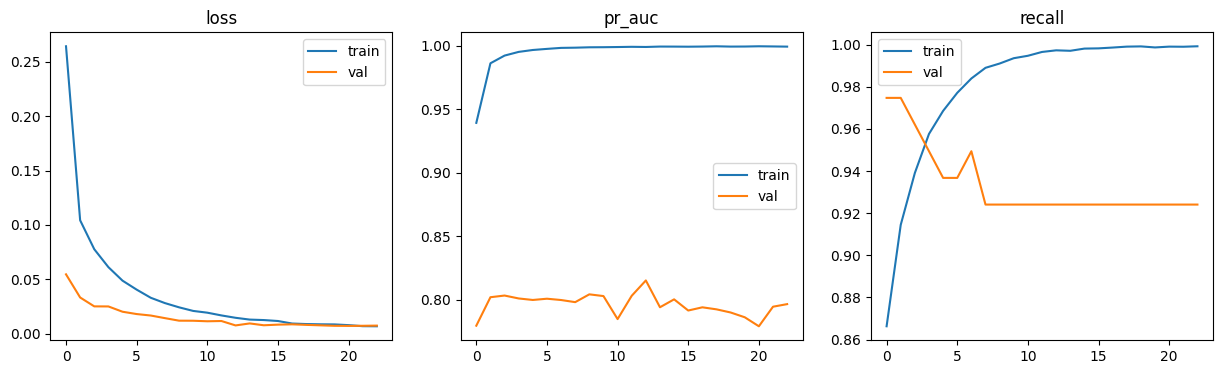

In [4]:
from keras import Sequential, Input, layers, callbacks, metrics

def initialize_model():
    model = Sequential([
        Input(shape=(X_train_bal.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        loss="binary_crossentropy",
        optimizer="adam",
        metrics=[metrics.Precision(name="precision"),
                 metrics.Recall(name="recall"),
                 metrics.AUC(curve="PR", name="pr_auc")],
    )
    return model

model = initialize_model()

es = callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=10, restore_best_weights=True)

history = model.fit(
    X_train_bal, y_train_bal,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=256,
    callbacks=[es], verbose=0,
)
print("Durduğu epoch:", len(history.history["loss"]), "→ en iyi:", int(np.argmax(history.history["val_pr_auc"])) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m in zip(axes, ["loss", "pr_auc", "recall"]):
    ax.plot(history.history[m], label="train")
    ax.plot(history.history["val_" + m], label="val")
    ax.set_title(m); ax.legend()
plt.show()

0.5 eşiğinde → val precision = 0.497
Seçilen eşik = 0.974 → val precision = 0.852, val recall = 0.873


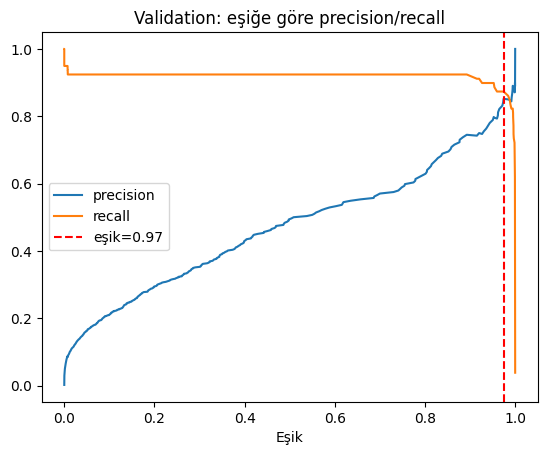

In [5]:
from sklearn.metrics import precision_recall_curve

proba_val = model.predict(X_val, verbose=0).ravel()
prec, rec, esikler = precision_recall_curve(y_val, proba_val)

# Hedef: val recall ≥ 0.85 (testin 0.75'ine güvenlik payı) iken precision'ı en yüksek eşik
uygun = rec[:-1] >= 0.85
en_iyi = np.argmax(np.where(uygun, prec[:-1], -1))
esik = esikler[en_iyi]

print(f"0.5 eşiğinde → val precision = {prec[np.searchsorted(esikler, 0.5)]:.3f}")
print(f"Seçilen eşik = {esik:.3f} → val precision = {prec[en_iyi]:.3f}, val recall = {rec[en_iyi]:.3f}")

plt.plot(esikler, prec[:-1], label="precision")
plt.plot(esikler, rec[:-1], label="recall")
plt.axvline(esik, color="red", linestyle="--", label=f"eşik={esik:.2f}")
plt.xlabel("Eşik"); plt.legend(); plt.title("Validation: eşiğe göre precision/recall")
plt.show()

### 🧪 Kodunu Test Et

Orijinal dengesiz veri kümesinin (`X_test`, `y_test`) temsil edici bir örneğinde gerçek test performansınızın altında kalan sonuçları `precision` ve `recall` değişkenlerine kaydedin.

In [7]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix

y_pred_test = (model.predict(X_test, verbose=0).ravel() >= esik).astype(int)

precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
print(f"TEST → precision = {precision:.3f}, recall = {recall:.3f}")
print(confusion_matrix(y_test, y_pred_test))

TEST → precision = 0.796, recall = 0.755
[[56845    19]
 [   24    74]]


In [8]:
from nbresult import ChallengeResult

result = ChallengeResult('solution',
    precision=precision,
    recall=recall,
    fraud_number=len(y_test[y_test == 1]),
    non_fraud_number=len(y_test[y_test == 0]),
)

result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/kaanu/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/kaanu/code/sprint-18/03-Optimizers-Fitting/S18D3-S-Data-credit-card-challenge/tests
plugins: typeguard-4.4.2, anyio-4.8.0
collecting ... collected 2 items

test_solution.py::TestSolution::test_is_score_good_enough PASSED         [ 50%]
test_solution.py::TestSolution::test_is_test_set_representative PASSED   [100%]

============================== 2 passed in 0.02s ===============================


💯 You can commit your code:

git add tests/solution.pickle

git commit -m 'Completed solution step'

git push origin master



## 🏁 İsteğe bağlı: Bu zorluk için Google'ın çözümünü okuyun
Bu oturumdaki tüm zorlukları tamamladığınız için tebrikler!

Son olarak, Google'ın kendi çözümünü doğrudan [Colab'da buradan](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/structured_data/imbalanced_data.ipynb) okuyun. 

İlginç teknikler ve en iyi uygulamaları keşfedeceksiniz.